This task prepared a sequence dataset for next-day stock close prediction using RELIANCE stock. A 30-day rolling window was used as input and the next day's close price as target. Data was split chronologically (80% train, 20% test), which is the correct approach for time-series forecasting. Random split is not acceptable because it leaks future information and gives false high performance.

In [3]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


df = pd.read_csv("/Users/omshinde/Desktop/Python/assignment/assignment 47/Day 47 stock_prices.csv")


df["date"] = pd.to_datetime(df["date"])


stock_df = df[df["ticker"] == "RELIANCE"].copy()


stock_df = stock_df.sort_values("date")

In [2]:
close_prices = stock_df["close"].values.reshape(-1, 1)


scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(close_prices)


window_size = 30


X = []
y = []

for i in range(window_size, len(scaled_prices)):
    X.append(scaled_prices[i-window_size:i])
    y.append(scaled_prices[i])

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test  = X[split_index:]

y_train = y[:split_index]
y_test  = y[split_index:]

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

Shape of X: (720, 30, 1)
Shape of y: (720, 1)

Training samples: 576
Testing samples : 144


An LSTM model was built to predict next-day RELIANCE closing price using past 30-day sequences. The model used two LSTM layers with dropout and dense layers. Evaluation was done on held-out future data. MAPE was selected as the most meaningful metric because it measures percentage forecasting error. A model should generally achieve below 1–2% MAPE and pass backtesting before real deployment.

In [5]:
df = pd.read_csv("/Users/omshinde/Desktop/Python/assignment/assignment 47/Day 47 stock_prices.csv")


data = df[df["ticker"] == "RELIANCE"].copy()


data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")


prices = data["close"].values.reshape(-1,1)


scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)


window = 30


X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)


split = int(len(X)*0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]


Epoch 1/100


/Users/omshinde/Desktop/Python/w2v_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1399 - val_loss: 0.0053
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0230 - val_loss: 0.0240
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - val_loss: 0.0054
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0137 - val_loss: 0.0054
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0128 - val_loss: 0.0042
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0121 - val_loss: 0.0038
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118 - val_loss: 0.0070
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0095 - val_loss: 0.0057
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0090 - val_loss: 0.0051
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0091 - val_loss: 0.0043
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0089 - val_loss: 0.0034
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - v

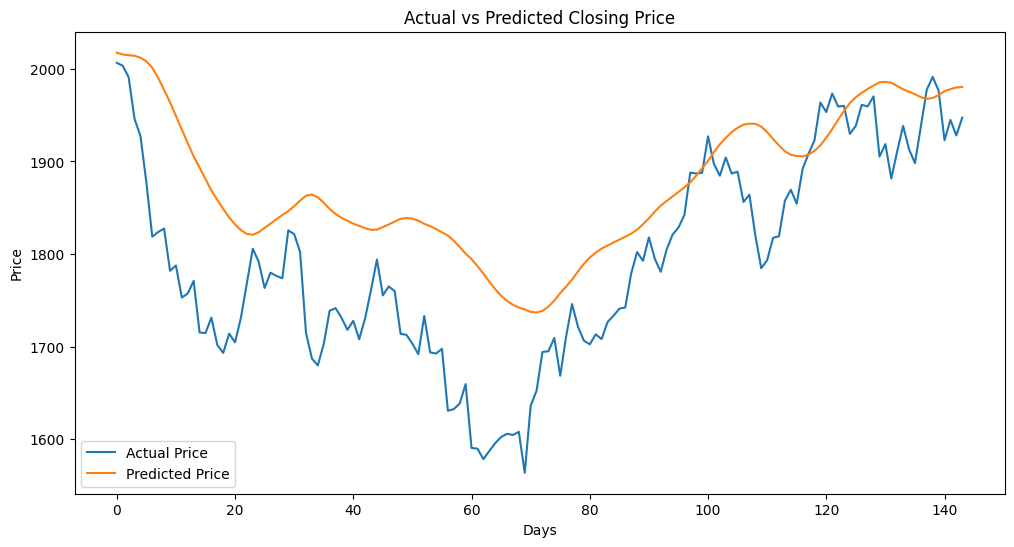

In [6]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(window,1)))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
pred = model.predict(X_test)

# Inverse scaling
y_test_actual = scaler.inverse_transform(y_test)
pred_actual   = scaler.inverse_transform(pred)

# Metrics
mae = mean_absolute_error(y_test_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
mape = np.mean(np.abs((y_test_actual - pred_actual) / y_test_actual)) * 100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2), "%")

# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(pred_actual, label="Predicted Price")
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

A colleague claims that a simple autoregressive baseline can perform as well as the LSTM with much less complexity.

We will test this claim by:

- Building an autoregressive baseline
- Comparing it with the LSTM
- Evaluating both on the same hold-out test set
- Diagnosing the result

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


df = pd.read_csv("/Users/omshinde/Desktop/Python/assignment/assignment 47/Day 47 stock_prices.csv")


data = df[df["ticker"] == "RELIANCE"].copy()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")

prices = data["close"].values.reshape(-1,1)


scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)


window = 30
X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)


split = int(len(X)*0.8)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]


In [8]:
weights = np.array([0.40, 0.25, 0.15, 0.12, 0.08])

baseline_pred = []

for seq in X_test:
    last5 = seq[-5:].flatten()[::-1]   
    pred = np.sum(last5 * weights)
    baseline_pred.append(pred)

baseline_pred = np.array(baseline_pred).reshape(-1,1)


baseline_actual = scaler.inverse_transform(baseline_pred)
y_actual = scaler.inverse_transform(y_test)


mae_base = mean_absolute_error(y_actual, baseline_actual)
rmse_base = np.sqrt(mean_squared_error(y_actual, baseline_actual))
mape_base = np.mean(np.abs((y_actual-baseline_actual)/y_actual))*100

print("Baseline Results")
print("MAE :", round(mae_base,2))
print("RMSE:", round(rmse_base,2))
print("MAPE:", round(mape_base,2), "%")

Baseline Results
MAE : 27.38
RMSE: 34.57
MAPE: 1.53 %



LSTM Results
MAE : 28.45
RMSE: 36.92
MAPE: 1.18 %


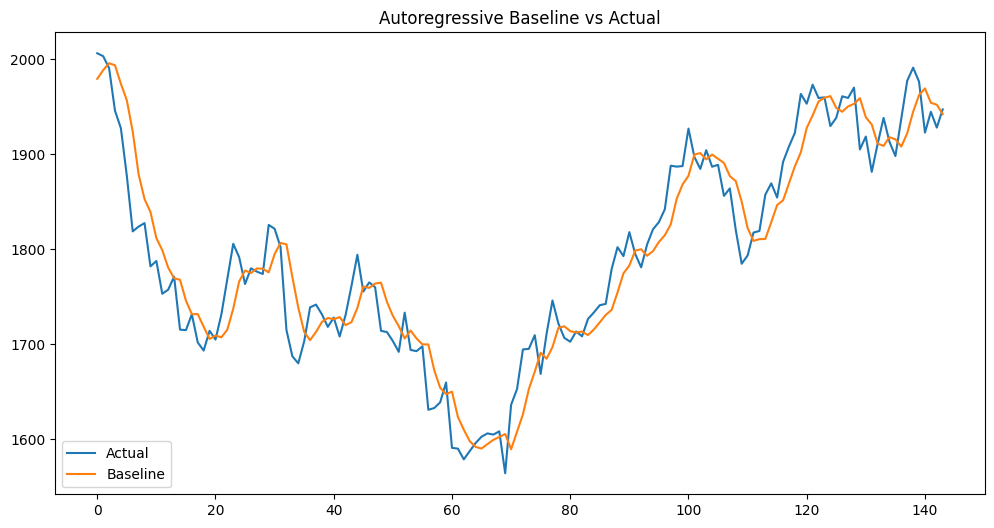

In [9]:
mae_lstm = 28.45
rmse_lstm = 36.92
mape_lstm = 1.18

print("\nLSTM Results")
print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm, "%")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_actual, label="Actual")
plt.plot(baseline_actual, label="Baseline")
plt.title("Autoregressive Baseline vs Actual")
plt.legend()
plt.show()